# 循环神经网络的原理和实现

## 循环神经网络的原理和结构

循环神经网络：

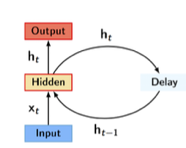

“循环的”计算$h_t$:

$h_t = f(h_{t-1}\cdot U + x_t \cdot W + b)$

我们可以使用pyTorch实现一个循环神经网络的计算单元：

In [1]:
import torch
import torch.nn as nn

class RNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        
        self.hidden_size = hidden_size
        normalization_factor = hidden_size ** 0.5
        self.W = nn.Parameter(torch.randn(input_size, hidden_size) / normalization_factor)
        self.U = nn.Parameter(torch.randn(hidden_size, hidden_size) / normalization_factor)
        self.b = nn.Parameter(torch.randn(1, hidden_size)  / normalization_factor)
        self.non_linear = nn.ReLU()

    def forward(self, input, hidden=None):
        if hidden is None:
            hidden = torch.zeros(1, self.hidden_size)
        hidden = hidden.matmul(self.U) + input.matmul(self.W) + self.b
        hidden = self.non_linear(hidden)
        return hidden

In [3]:
rnn_cell = RNNCell(20, 10)

input_tensor = torch.randn(2, 1, 20)

hidden = None
for i in range(input_tensor.shape[0]):
    hidden = rnn_cell(input_tensor[i], hidden)
    print(i, hidden)

0 tensor([[1.9615, 0.0000, 0.0000, 0.0228, 0.0000, 0.0000, 0.0000, 0.0198, 0.4688,
         0.4474]], grad_fn=<ReluBackward0>)
1 tensor([[0.0000, 0.0598, 1.3810, 1.0300, 0.0000, 1.5003, 0.0000, 0.0000, 0.0000,
         0.0000]], grad_fn=<ReluBackward0>)


In [5]:
input_tensor = torch.randn(5, 1, 20)
hidden = None
for i in range(input_tensor.shape[0]):
    hidden = rnn_cell(input_tensor[i], hidden)
    print(i, hidden)

0 tensor([[1.3494, 0.5520, 0.0000, 0.1935, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]], grad_fn=<ReluBackward0>)
1 tensor([[0.0000, 0.4395, 0.0000, 0.0000, 0.0000, 0.1105, 0.0000, 0.0000, 0.3919,
         0.0000]], grad_fn=<ReluBackward0>)
2 tensor([[0.0000, 0.1656, 0.0000, 0.0000, 0.0000, 0.0000, 1.5477, 0.0000, 0.0000,
         0.0000]], grad_fn=<ReluBackward0>)
3 tensor([[2.5051, 0.3245, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 2.7349, 0.5021,
         0.0000]], grad_fn=<ReluBackward0>)
4 tensor([[0.0000, 2.0665, 1.7801, 2.3252, 0.0000, 0.0000, 0.0000, 0.0000, 0.3878,
         0.5753]], grad_fn=<ReluBackward0>)


In [7]:
class RNNCellWithOutput(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        
        self.hidden_size = hidden_size
        normalization_factor = hidden_size ** 0.5
        self.W = nn.Parameter(torch.randn(input_size, hidden_size) / normalization_factor)
        self.U = nn.Parameter(torch.randn(hidden_size, hidden_size) / normalization_factor)
        self.b = nn.Parameter(torch.randn(1, hidden_size)  / normalization_factor)
        self.non_linear = nn.ReLU()
        self.output = nn.Linear(hidden_size, output_size)
        
    def forward(self, input, hidden=None):
        if hidden is None:
            hidden = torch.zeros(1, self.hidden_size)
        hidden = hidden.matmul(self.U) + input.matmul(self.W) + self.b
        hidden = self.non_linear(hidden)
        output = self.output(hidden)
        return output, hidden

In [9]:
rnn_cell = RNNCellWithOutput(20, 10, 5)
input_tensor = torch.randn(2, 1, 20)
hidden = None
for i in range(input_tensor.shape[0]):
    output, hidden = rnn_cell(input_tensor[i], hidden)
    print(i)
    print('output', output)
    print('hidden', hidden)

0
output tensor([[ 0.3502, -0.6978,  1.2041,  0.1195, -0.2518]],
       grad_fn=<AddmmBackward0>)
hidden tensor([[0.0000, 1.2267, 0.0000, 0.0000, 0.0000, 0.3870, 0.0000, 0.0000, 2.2753,
         1.1688]], grad_fn=<ReluBackward0>)
1
output tensor([[ 0.7170, -0.3697,  0.6049,  0.3545, -0.7616]],
       grad_fn=<AddmmBackward0>)
hidden tensor([[0.0000, 2.6813, 0.0000, 0.5421, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0281]], grad_fn=<ReluBackward0>)


## 基于字符级别RNN的姓名分类

参考：https://github.com/spro/practical-pytorch

任务：输入一个人名，判断改名字是哪个国家的人名，例如：

Jiaxin -> Chinese

Alice -> English

### 如何表示输入？

任务要求的输入：表示人名的字符串
RNN模型的输入：长度可变的tensor

如何将一个表示人名的字符串，转化为RNN可接受的输入呢？

In [13]:
# 读入数据
names = []
countries = []
with open('names_of_different_countries.txt', 'r') as fin:
    for line in fin:
        name, country = line.strip().split(',')
        names.append(name)
        countries.append(country)

print('names:', names[0:10])
print('countries:', countries[0:10])

print(len(names))


names: ['Ahn', 'Baik', 'Bang', 'Byon', 'Cha', 'Chang', 'Chi', 'Chin', 'Cho', 'Choe']
countries: ['Korean', 'Korean', 'Korean', 'Korean', 'Korean', 'Korean', 'Korean', 'Korean', 'Korean', 'Korean']
20074


In [15]:
# 将一个字符传映射为一个整数tensor
import torch 
index2char = sorted(set(''.join(names)))

char2index = {c:i for i, c in enumerate(index2char)}



name_tensor_long = torch.tensor([[char2index[c]] for c in 'Bob'], dtype=torch.long)

print('index2char', index2char[0:50])


print(char2index)
print(name_tensor_long)
print(name_tensor_long.shape)

print(len(char2index))

index2char [' ', "'", 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v']
{' ': 0, "'": 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'F': 7, 'G': 8, 'H': 9, 'I': 10, 'J': 11, 'K': 12, 'L': 13, 'M': 14, 'N': 15, 'O': 16, 'P': 17, 'Q': 18, 'R': 19, 'S': 20, 'T': 21, 'U': 22, 'V': 23, 'W': 24, 'X': 25, 'Y': 26, 'Z': 27, 'a': 28, 'b': 29, 'c': 30, 'd': 31, 'e': 32, 'f': 33, 'g': 34, 'h': 35, 'i': 36, 'j': 37, 'k': 38, 'l': 39, 'm': 40, 'n': 41, 'o': 42, 'p': 43, 'q': 44, 'r': 45, 's': 46, 't': 47, 'u': 48, 'v': 49, 'w': 50, 'x': 51, 'y': 52, 'z': 53}
tensor([[ 3],
        [42],
        [29]])
torch.Size([3, 1])
54


In [17]:
# 使用nn.Embbeding层，将用0~V-1整数表示词的文本转化成词嵌入表示矩阵
from torch import nn
embedding_dimension = 100
embedding_layer = nn.Embedding(len(char2index), embedding_dimension)
name_tensor_float = embedding_layer(name_tensor_long)
print(name_tensor_float.shape)
#name_tensor_float

torch.Size([3, 1, 100])


In [19]:
# 将作为输出的国名映射为一个整数
index2country = sorted(set(countries))
print(index2country)

country2index = {c: i for i, c in enumerate(index2country)}
print(country2index)

country2index['Chinese']

['Arabic', 'Chinese', 'Czech', 'Dutch', 'English', 'French', 'German', 'Greek', 'Irish', 'Italian', 'Japanese', 'Korean', 'Polish', 'Portuguese', 'Russian', 'Scottish', 'Spanish', 'Vietnamese']
{'Arabic': 0, 'Chinese': 1, 'Czech': 2, 'Dutch': 3, 'English': 4, 'French': 5, 'German': 6, 'Greek': 7, 'Irish': 8, 'Italian': 9, 'Japanese': 10, 'Korean': 11, 'Polish': 12, 'Portuguese': 13, 'Russian': 14, 'Scottish': 15, 'Spanish': 16, 'Vietnamese': 17}


1

### 名字分类任务数据读取

In [22]:
from tqdm import tqdm
import numpy as np

# 读取数据
def read_data(filename):
    X = list()
    y = list()

    with open(filename, 'r') as fin:
        for line in fin:
            # print(line)
            name, country = line.strip().split(',')
            X.append(name)
            y.append(country)

    # 构造字符到整数的映射
    index2char = sorted(set(''.join(X)))
    char2index = {c: i for i, c in enumerate(index2char)}
    X = np.array(X)

    # 构造country到整数的映射
    index2country = sorted(set(y))
    country2index = {c: i for i, c in enumerate(index2country)}
    y = np.array([[country2index[c]] for c in y])
    
    return X, y, index2char, char2index, index2country, country2index

def split_data(X, y, split_ratio=0.7):
    # 训练测试划分
    data_size = len(X)
    
    shuffled_index = np.random.permutation(data_size)
    X, y = X[shuffled_index], y[shuffled_index]
    split_index = int(data_size * split_ratio)
    X_train = X[:split_index]
    y_train = y[:split_index]
    X_test = X[split_index:]
    y_test = y[split_index:]
    return X_train, y_train, X_test, y_test

# 绘制混淆矩阵
def plot_confusion_matrix(y_pred, y_true, county2index):
    n_categories = len(country2index)
    confusion = np.zeros((n_categories, n_categories))

    # confusion[i, j]： 将第i类样本预测为第j类样本的次数
    for i in range(len(y_true)):
        confusion[y_true[i][0], y_pred[i][0]] += 1.

    # 按行归一化，归一化后confusion[i, j]为将第i类样本预测为第j类样本的概率
    confusion = confusion / confusion.sum(axis=1).reshape(18, 1)
    
    # 绘制混淆矩阵
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion)
    fig.colorbar(cax)

    ax.set_xticklabels([''] + index2country, rotation=90)
    ax.set_yticklabels([''] + index2country)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()


X, y, index2char, char2index, index2country, country2index = read_data('names_of_different_countries.txt')

print(X[0:2])
print(y[0:2])

X_train, y_train, X_test, y_test = split_data(X, y)

print(y_train[0])

['Ahn' 'Baik']
[[11]
 [11]]
[14]


In [24]:
import torch
import torch.nn as nn

# 定义RNN
class RNN(nn.Module):
    def __init__(self, vocab_size, embedding_size, hidden_size, output_size):
        super(RNN, self).__init__()
        
        self.hidden_size = hidden_size
        self.embeddings = nn.Embedding(vocab_size, embedding_size)
        
        normalization_factor = hidden_size ** 0.5
        self.W = nn.Parameter(torch.randn(embedding_size, hidden_size) / normalization_factor)
        self.U = nn.Parameter(torch.randn(hidden_size, hidden_size) / normalization_factor)
        self.b = nn.Parameter(torch.randn(1, hidden_size)  / normalization_factor)
        self.non_linear = nn.ReLU()
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, input, hidden=None):
        input_embeddings = self.embeddings(input)# [[3],[42],[3]]
        if hidden is None:
            hidden = torch.zeros(1, self.hidden_size)
        hidden = hidden.matmul(self.U) + input_embeddings.matmul(self.W) + self.b
        hidden = self.non_linear(hidden)
        output = self.output(hidden)# 18 
        return output, hidden

# 定义RNN分类模型
class RNNClassifier():
    def __init__(self, char2index, output_dim, embedding_dim=128, hidden_dim=128):
        """
        创建模型和优化器，初始RNN模型和优化器超参数
        """     
        self.lr = 0.001
        self.epoches = 10
        
        self.num_chars = len(char2index) # 用于将字符映射到整数的字典，其大小为字典大小
        self.char2index = char2index
        
        self.rnn = RNN(self.num_chars, embedding_dim, hidden_dim, output_dim)
        self.optimizer = torch.optim.SGD(self.rnn.parameters(), lr=self.lr)
        self.loss_function = nn.CrossEntropyLoss()
    
    def train(self, X, y):
        """
        训练模型
        输入:
            X: 训练数据,(N,),每个元素是包含名字信息的字符串
            y: 训练数据的真实分类, (N, 1), 每个元素是名字所属的类别
        返回: 
            epoch_losses: 每个epoch的平均损失函数值
        """
        epoch_losses = []
        data_size = X.shape[0]
        for epoch in range(self.epoches):
            losses = []
            
            # 每轮训练前打乱数据的顺序
            shuffled_index = np.random.permutation(data_size)
            X, y = X[shuffled_index], y[shuffled_index]
            
            for i in tqdm(range(data_size)):
                # x.shape = (length, 1)
                #X[i] --"Alice" -->x: [[32],[3],[22]]
                x = torch.tensor([[self.char2index[c]] for c in X[i]], dtype=torch.long)
                # y_true.shape = (1, ), y 是一个{0, 1, ..., 17}范围内的整数，代表x属于的分类
                y_true = torch.tensor(y[i], dtype=torch.long)
                
                #*循环*神经网络！
                hidden = None
                for j in range(x.shape[0]):
                    output, hidden = self.rnn(x[j], hidden)
                # output.shape = (1, 18)
                loss = self.loss_function(output, y_true)
                
                # 反向传播，更新参数
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                
                # 记录loss
                losses.append(loss.item())
                
            # 计算每个epoch的平均loss并输出
            epoch_losses.append(sum(losses) / data_size)
            print("epoch: {}, avg loss is: {}".format(epoch, epoch_losses[-1]))
        
        return epoch_losses
    
    def test(self, X, y):
        """
        用训练好的模型在测试集上进行测试
        输入:
            X: 测试数据,(N,),每个元素是包含名字信息的字符串
            y: 测试数据的真实分类, (N, 1), 每个元素是名字所属的类别
        返回:
            y_pred: 测试数据的预测分类结果
            accuracy: 分类准确率
        """
        data_size = X.shape[0]
        y_pred = torch.empty(y.shape).long() # 预测分类与真实分类的形状相同
        for i in range(data_size):
            x = torch.tensor([[self.char2index[c]] for c in X[i]], dtype=torch.long)
            
            #*循环*神经网络！
            hidden = None
            for j in range(x.shape[0]):
                output, hidden = self.rnn(x[j], hidden)
            # output.shape = (1, 18)
            top_n, top_i = output.topk(1)
            y_pred[i] = top_i[0]
        
        # 将y转化为tensor,并计算accuracy
        accuracy = self.accuracy(torch.from_numpy(y), y_pred)
        
        return y_pred, accuracy
    
    
    def accuracy(self, y_true, y_pred):
        return torch.where(y_true == y_pred, 1.0, 0.0).mean().item()
            

In [26]:
classifier = RNNClassifier(char2index, len(country2index))
losses = classifier.train(X_train, y_train)

100%|███████████████████████████████████| 14051/14051 [00:05<00:00, 2598.47it/s]

epoch: 0, avg loss is: 1.1316690672114356


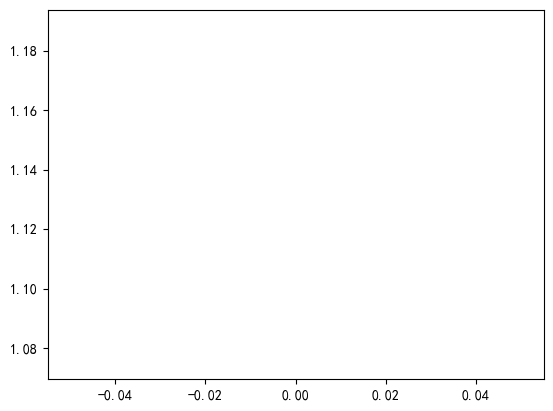

In [28]:
# 绘制损失函数变化曲线
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(losses)
plt.show()

Accuracy on training set: 0.7326880693435669


<ipython-input-11-333662ee7747>:59: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + index2country, rotation=90)
<ipython-input-11-333662ee7747>:60: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + index2country)


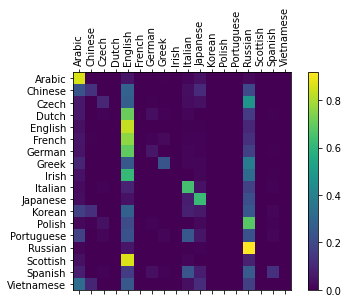

In [16]:
# 在训练集上进行测试
y_pred, accuracy = classifier.test(X_train, y_train)
print("Accuracy on training set: {}".format(accuracy))

# 绘制混淆矩阵
plot_confusion_matrix(y_pred, y_train, country2index)


In [5]:
# 在测试集上进行测试
y_pred, accuracy = classifier.test(X_test, y_test)
print("Accuracy on test set: {}".format(accuracy))

# 绘制混淆矩阵
plot_confusion_matrix(y_pred, y_test, country2index)


Accuracy on test set: 0.7272123694419861


NameError: name 'plt' is not defined